In [1]:
# Sel 1: Import Library
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("Import berhasil!")

Import berhasil!


In [2]:
# Sel 2: Load Data Processed
PROCESSED_DIR = '../data/processed/'
X_data = np.load(PROCESSED_DIR + 'X_data.npy')
y_data = np.load(PROCESSED_DIR + 'y_data.npy')
print(f"Shape X: {X_data.shape}, Shape y: {y_data.shape}")

Shape X: (200, 224, 224, 3), Shape y: (200,)


In [3]:
# Sel 3: Membangun EfficientNet-B3 Feature Extractor
print("Membangun model EfficientNet-B3...")
# include_top=False membuang layer klasifikasi bawaan, pooling='avg' menghasilkan vektor 1D
feature_extractor = EfficientNetB3(weights='imagenet', include_top=False, pooling='avg')

print("Mengekstraksi fitur dari dataset...")
X_features = feature_extractor.predict(X_data, batch_size=16)
print(f"Dimensi fitur hasil ekstraksi: {X_features.shape}") # Seharusnya (Jumlah Data, 1536)

Membangun model EfficientNet-B3...
Mengekstraksi fitur dari dataset...
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 693ms/step
Dimensi fitur hasil ekstraksi: (200, 1536)


In [4]:
# Sel 4: Split Data (80% Train, 20% Test) Sesuai Skema Jurnal
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_data, test_size=0.2, random_state=42, stratify=y_data
)

In [5]:
# Sel 5: Normalisasi Fitur menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Sel 6: Inisialisasi Model Klasifikasi Klasik
import joblib

# Parameter disesuaikan persis dengan metode jurnal, ditambah probability=True untuk SVM
models = {
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, metric='euclidean')
}


Training SVM (RBF)...
Akurasi: 1.0000
Macro F1-Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        20
        Sick       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



/home/harry/lettuce-disease-hybrid-ml/env/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


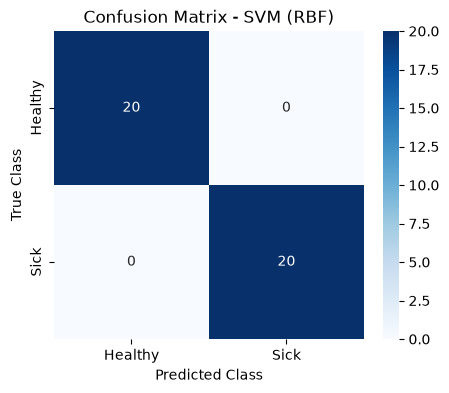

>>> Model SVM (RBF), Scaler, dan Feature Extractor berhasil disimpan! <<<

Training Random Forest...
Akurasi: 0.9750
Macro F1-Score: 0.9750

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.95      0.97        20
        Sick       0.95      1.00      0.98        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



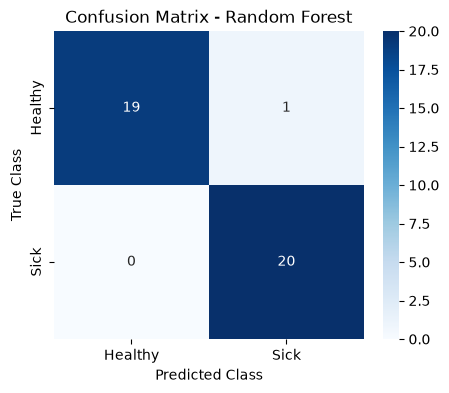


Training KNN...
Akurasi: 0.9250
Macro F1-Score: 0.9246

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.85      0.92        20
        Sick       0.87      1.00      0.93        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



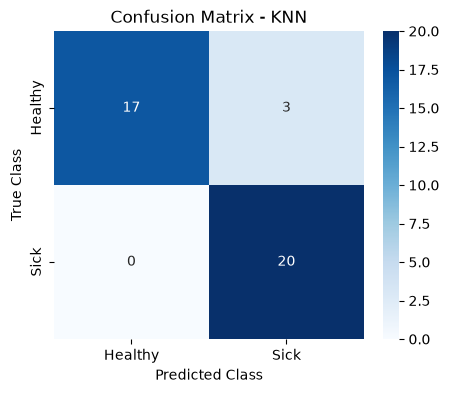

In [7]:
# Sel 7: Pelatihan, Evaluasi, dan Simpan Model
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")
    
    # Training
    model.fit(X_train_scaled, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test_scaled)
    
    # Evaluasi menggunakan Akurasi dan Macro F1
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    
    print(f"Akurasi: {acc:.4f}")
    print(f"Macro F1-Score: {macro_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Healthy', 'Sick']))
    
    # Tampilkan Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Healthy', 'Sick'], 
                yticklabels=['Healthy', 'Sick'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()
    
    if name == "SVM (RBF)":
        joblib.dump(model, '../models/svm_model.pkl')
        joblib.dump(scaler, '../models/scaler.pkl')
        feature_extractor.save('../models/efficientnet_extractor.keras')
        print(f">>> Model {name}, Scaler, dan Feature Extractor berhasil disimpan! <<<")